In [107]:
# ============================================================
# NOTEBOOK 7
# ADVANCED FEATURE ENGINEERING
# Heart Disease Prediction Using Wearable Devices
# ============================================================

print("=" * 70)
print("ADVANCED FEATURE ENGINEERING")
print("=" * 70)

print("Purpose:")
print("Create meaningful health-related and interaction features")
print("to improve the heart disease prediction model.")

print("\nBaseline ANN Accuracy : 73.48%")
print("Baseline ANN ROC-AUC  : 0.8027")
print("=" * 70)

ADVANCED FEATURE ENGINEERING
Purpose:
Create meaningful health-related and interaction features
to improve the heart disease prediction model.

Baseline ANN Accuracy : 73.48%
Baseline ANN ROC-AUC  : 0.8027


In [108]:
# ============================================================
# CELL 2 - IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully.")

Libraries imported successfully.


In [109]:
# ============================================================
# CELL 3 - LOAD CLEANED DATASET
# ============================================================

input_path = "../data/processed_data/feature_engineered_dataset.csv"

df = pd.read_csv(input_path)

print("=" * 70)
print("DATASET LOADED")
print("=" * 70)

print("Rows    :", df.shape[0])
print("Columns :", df.shape[1])

print("\nFirst 5 rows:")
display(df.head())

DATASET LOADED
Rows    : 68036
Columns : 15

First 5 rows:


,age,gender,height,weight,Systolic_BP,Diastolic_BP,cholesterol,Glucose,smoke,Alcohol,Physical_Activity,Heart_Disease,BMI,Pulse_Pressure,MAP
0,50.4,2,168,62.0,110,80,1,1,0,0,1,0,21.97,30,90.00
1,55.4,1,156,85.0,140,90,3,1,0,0,1,1,34.93,50,106.67
2,51.7,1,165,64.0,130,70,3,1,0,0,0,1,23.51,60,90.00
3,48.3,2,169,82.0,150,100,1,1,0,0,1,1,28.71,50,116.67
4,47.9,1,156,56.0,100,60,1,1,0,0,0,0,23.01,40,73.33


In [110]:
# ============================================================
# CELL 4 - DISPLAY ALL COLUMNS
# ============================================================

print("=" * 70)
print("CURRENT DATASET COLUMNS")
print("=" * 70)

for i, column in enumerate(df.columns, start=1):
    print(f"{i:2}. {column}")

CURRENT DATASET COLUMNS
 1. age
 2. gender
 3. height
 4. weight
 5. Systolic_BP
 6. Diastolic_BP
 7. cholesterol
 8. Glucose
 9. smoke
10. Alcohol
11. Physical_Activity
12. Heart_Disease
13. BMI
14. Pulse_Pressure
15. MAP


In [111]:
# ============================================================
# CELL 5 - DATASET INFORMATION
# ============================================================

print("=" * 70)
print("DATASET INFORMATION")
print("=" * 70)

print("\nData types:")
display(df.dtypes)

print("\nMissing values:")
display(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

DATASET INFORMATION

Data types:


age                  float64
gender                 int64
height                 int64
weight               float64
Systolic_BP            int64
Diastolic_BP           int64
cholesterol            int64
Glucose                int64
smoke                  int64
Alcohol                int64
Physical_Activity      int64
Heart_Disease          int64
BMI                  float64
Pulse_Pressure         int64
MAP                  float64
dtype: object


Missing values:


age                  0
gender               0
height               0
weight               0
Systolic_BP          0
Diastolic_BP         0
cholesterol          0
Glucose              0
smoke                0
Alcohol              0
Physical_Activity    0
Heart_Disease        0
BMI                  0
Pulse_Pressure       0
MAP                  0
dtype: int64


Duplicate rows:
665


In [112]:
# ============================================================
# CELL 6 - IDENTIFY IMPORTANT HEALTH COLUMNS
# ============================================================

def find_column(possible_names, dataframe):
    """
    Find the first matching column from a list of possible names.
    Matching is case-insensitive.
    """

    column_map = {
        col.lower().strip(): col
        for col in dataframe.columns
    }

    for name in possible_names:
        if name.lower().strip() in column_map:
            return column_map[name.lower().strip()]

    return None


age_col = find_column(
    ["age", "Age", "age_years", "Age_Years"],
    df
)

height_col = find_column(
    ["height", "Height", "height_cm", "Height_cm"],
    df
)

weight_col = find_column(
    ["weight", "Weight", "weight_kg", "Weight_kg"],
    df
)

systolic_col = find_column(
    ["ap_hi", "Systolic_BP", "SystolicBP", "systolic_bp"],
    df
)

diastolic_col = find_column(
    ["ap_lo", "Diastolic_BP", "DiastolicBP", "diastolic_bp"],
    df
)

cholesterol_col = find_column(
    ["cholesterol", "Cholesterol"],
    df
)

target_col = find_column(
    ["Heart_Disease", "heart_disease", "cardio", "target"],
    df
)


print("=" * 70)
print("IDENTIFIED COLUMNS")
print("=" * 70)

print("Age          :", age_col)
print("Height       :", height_col)
print("Weight       :", weight_col)
print("Systolic BP  :", systolic_col)
print("Diastolic BP :", diastolic_col)
print("Cholesterol  :", cholesterol_col)
print("Target       :", target_col)

IDENTIFIED COLUMNS
Age          : age
Height       : height
Weight       : weight
Systolic BP  : Systolic_BP
Diastolic BP : Diastolic_BP
Cholesterol  : cholesterol
Target       : Heart_Disease


In [113]:
# ============================================================
# CELL 7 - CHECK TARGET VARIABLE
# ============================================================

if target_col is None:
    raise ValueError(
        "Heart_Disease target column was not found. "
        "Check the column names displayed in Cell 4."
    )

print("Target column:", target_col)

print("\nTarget distribution:")
display(df[target_col].value_counts())

print("\nTarget proportions:")
display(df[target_col].value_counts(normalize=True))

Target column: Heart_Disease

Target distribution:


Heart_Disease
0    34491
1    33545
Name: count, dtype: int64


Target proportions:


Heart_Disease
0    0.506952
1    0.493048
Name: proportion, dtype: float64

In [114]:
# ============================================================
# CELL 8 - CREATE BMI FEATURE
# ============================================================

if height_col is not None and weight_col is not None:

    # Convert height from centimeters to meters
    height_m = df[height_col] / 100

    # Avoid division by zero
    height_m = height_m.replace(0, np.nan)

    df["BMI_Advanced"] = df[weight_col] / (height_m ** 2)

    print("BMI_Advanced feature created successfully.")

else:
    print("Height or Weight column not found.")

BMI_Advanced feature created successfully.


In [115]:
# ============================================================
# CELL 9 - BMI CATEGORY
# ============================================================

if "BMI_Advanced" in df.columns:

    df["BMI_Category_Advanced"] = pd.cut(
        df["BMI_Advanced"],
        bins=[
            -np.inf,
            18.5,
            25,
            30,
            np.inf
        ],
        labels=[0, 1, 2, 3]
    ).astype(float)

    print("BMI category feature created.")

    print("\nBMI category distribution:")
    display(df["BMI_Category_Advanced"].value_counts().sort_index())

else:
    print("BMI_Advanced was not created.")

BMI category feature created.

BMI category distribution:


BMI_Category_Advanced
0.0      615
1.0    25431
2.0    24609
3.0    17381
Name: count, dtype: int64

In [116]:
# ============================================================
# CELL 10 - PULSE PRESSURE
# ============================================================

if systolic_col is not None and diastolic_col is not None:

    df["Pulse_Pressure_Advanced"] = (
        df[systolic_col] - df[diastolic_col]
    )

    print("Pulse_Pressure_Advanced created successfully.")

else:
    print("Blood pressure columns were not found.")

Pulse_Pressure_Advanced created successfully.


In [117]:
# ============================================================
# CELL 11 - MEAN ARTERIAL PRESSURE
# ============================================================

if systolic_col is not None and diastolic_col is not None:

    df["MAP_Advanced"] = (
        df[systolic_col] +
        (2 * df[diastolic_col])
    ) / 3

    print("MAP_Advanced created successfully.")

else:
    print("Blood pressure columns were not found.")

MAP_Advanced created successfully.


In [118]:
# ============================================================
# CELL 12 - BLOOD PRESSURE RATIO
# ============================================================

if systolic_col is not None and diastolic_col is not None:

    diastolic_safe = df[diastolic_col].replace(0, np.nan)

    df["BP_Ratio_Advanced"] = (
        df[systolic_col] / diastolic_safe
    )

    print("BP_Ratio_Advanced created successfully.")

else:
    print("Blood pressure columns were not found.")

BP_Ratio_Advanced created successfully.


In [119]:
# ============================================================
# CELL 13 - AGE IN YEARS
# ============================================================

if age_col is not None:

    age_median = df[age_col].median()

    if age_median > 150:

        # Age appears to be stored in days
        df["Age_Years_Advanced"] = df[age_col] / 365.25

        print("Age appears to be stored in days.")
        print("Created Age_Years_Advanced.")

    else:

        # Age already appears to be in years
        df["Age_Years_Advanced"] = df[age_col]

        print("Age already appears to be in years.")
        print("Created Age_Years_Advanced.")

else:
    print("Age column was not found.")

Age already appears to be in years.
Created Age_Years_Advanced.


In [120]:
# ============================================================
# CELL 14 - AGE SQUARED
# ============================================================

if "Age_Years_Advanced" in df.columns:

    df["Age_Squared_Advanced"] = (
        df["Age_Years_Advanced"] ** 2
    )

    print("Age_Squared_Advanced created successfully.")

else:
    print("Age_Years_Advanced was not found.")

Age_Squared_Advanced created successfully.


In [121]:
# ============================================================
# CELL 15 - AGE × SYSTOLIC BLOOD PRESSURE
# ============================================================

if (
    "Age_Years_Advanced" in df.columns
    and systolic_col is not None
):

    df["Age_x_SystolicBP"] = (
        df["Age_Years_Advanced"] *
        df[systolic_col]
    )

    print("Age_x_SystolicBP created successfully.")

else:
    print("Required columns not found.")

Age_x_SystolicBP created successfully.


In [122]:
# ============================================================
# CELL 16 - AGE × CHOLESTEROL
# ============================================================

if (
    "Age_Years_Advanced" in df.columns
    and cholesterol_col is not None
):

    df["Age_x_Cholesterol"] = (
        df["Age_Years_Advanced"] *
        df[cholesterol_col]
    )

    print("Age_x_Cholesterol created successfully.")

else:
    print("Required columns not found.")

Age_x_Cholesterol created successfully.


In [123]:
# ============================================================
# CELL 17 - BMI × CHOLESTEROL
# ============================================================

if (
    "BMI_Advanced" in df.columns
    and cholesterol_col is not None
):

    df["BMI_x_Cholesterol"] = (
        df["BMI_Advanced"] *
        df[cholesterol_col]
    )

    print("BMI_x_Cholesterol created successfully.")

else:
    print("Required columns not found.")

BMI_x_Cholesterol created successfully.


In [124]:
# ============================================================
# CELL 18 - BLOOD PRESSURE × CHOLESTEROL
# ============================================================

if (
    systolic_col is not None
    and cholesterol_col is not None
):

    df["SystolicBP_x_Cholesterol"] = (
        df[systolic_col] *
        df[cholesterol_col]
    )

    print("SystolicBP_x_Cholesterol created successfully.")

else:
    print("Required columns not found.")

SystolicBP_x_Cholesterol created successfully.


In [125]:
# ============================================================
# CELL 19 - BMI × AGE
# ============================================================

if (
    "BMI_Advanced" in df.columns
    and "Age_Years_Advanced" in df.columns
):

    df["BMI_x_Age"] = (
        df["BMI_Advanced"] *
        df["Age_Years_Advanced"]
    )

    print("BMI_x_Age created successfully.")

else:
    print("Required columns not found.")

BMI_x_Age created successfully.


In [126]:
# ============================================================
# CELL 20 - DISPLAY NEW FEATURES
# ============================================================

advanced_keywords = [
    "Advanced",
    "_x_",
    "Age_x_",
    "BMI_x_",
    "SystolicBP_x_"
]

new_features = []

for col in df.columns:

    if any(keyword in col for keyword in advanced_keywords):
        new_features.append(col)

print("=" * 70)
print("ADVANCED FEATURES CREATED")
print("=" * 70)

for i, col in enumerate(new_features, start=1):
    print(f"{i:2}. {col}")

print("\nNumber of advanced features:", len(new_features))

ADVANCED FEATURES CREATED
 1. BMI_Advanced
 2. BMI_Category_Advanced
 3. Pulse_Pressure_Advanced
 4. MAP_Advanced
 5. BP_Ratio_Advanced
 6. Age_Years_Advanced
 7. Age_Squared_Advanced
 8. Age_x_SystolicBP
 9. Age_x_Cholesterol
10. BMI_x_Cholesterol
11. SystolicBP_x_Cholesterol
12. BMI_x_Age

Number of advanced features: 12


In [127]:
# ============================================================
# CELL 21 - STATISTICS OF NEW FEATURES
# ============================================================

display(
    df[new_features].describe().T
)

,count,mean,std,min,25%,50%,75%,max
BMI_Advanced,68036.0,27.284352,4.849341,15.012197,23.875115,26.296567,30.091432,44.997166
BMI_Category_Advanced,68036.0,1.863602,0.804250,0.000000,1.000000,2.000000,3.000000,3.000000
Pulse_Pressure_Advanced,68036.0,45.209007,11.723531,-50.000000,40.000000,40.000000,50.000000,135.000000
MAP_Advanced,68036.0,96.335058,10.858774,60.000000,93.333333,93.333333,103.333333,153.333333
BP_Ratio_Advanced,68036.0,1.560654,0.148212,0.615385,1.500000,1.500000,1.625000,3.250000
Age_Years_Advanced,68036.0,53.322218,6.763199,29.600000,48.400000,54.000000,58.400000,65.000000
Age_Squared_Advanced,68036.0,2888.999088,708.940379,876.160000,2342.560000,2916.000000,3410.560000,4225.000000
Age_x_SystolicBP,68036.0,6767.372401,1351.158684,2960.000000,5808.000000,6708.000000,7588.275000,12880.000000
Age_x_Cholesterol,68036.0,73.345163,39.989141,29.600000,50.000000,56.200000,64.600000,194.700000
BMI_x_Cholesterol,68036.0,37.735290,21.872534,15.012197,24.221453,27.885187,41.228420,134.991497


In [128]:
# ============================================================
# CELL 22 - CHECK NaN AND INFINITE VALUES
# ============================================================

print("=" * 70)
print("CHECKING NEW FEATURES")
print("=" * 70)

print("\nNaN values:")
print(df[new_features].isnull().sum())

print("\nInfinite values:")

infinite_counts = np.isinf(
    df[new_features].select_dtypes(include=np.number)
).sum()

print(infinite_counts)

CHECKING NEW FEATURES

NaN values:
BMI_Advanced                0
BMI_Category_Advanced       0
Pulse_Pressure_Advanced     0
MAP_Advanced                0
BP_Ratio_Advanced           0
Age_Years_Advanced          0
Age_Squared_Advanced        0
Age_x_SystolicBP            0
Age_x_Cholesterol           0
BMI_x_Cholesterol           0
SystolicBP_x_Cholesterol    0
BMI_x_Age                   0
dtype: int64

Infinite values:
BMI_Advanced                0
BMI_Category_Advanced       0
Pulse_Pressure_Advanced     0
MAP_Advanced                0
BP_Ratio_Advanced           0
Age_Years_Advanced          0
Age_Squared_Advanced        0
Age_x_SystolicBP            0
Age_x_Cholesterol           0
BMI_x_Cholesterol           0
SystolicBP_x_Cholesterol    0
BMI_x_Age                   0
dtype: int64


In [129]:
# ============================================================
# CELL 23 - HANDLE INFINITE VALUES
# ============================================================

# Replace positive and negative infinity with NaN
df.replace(
    [np.inf, -np.inf],
    np.nan,
    inplace=True
)

# Fill numerical missing values with median
numeric_columns = df.select_dtypes(
    include=np.number
).columns

for col in numeric_columns:

    if df[col].isnull().sum() > 0:

        df[col] = df[col].fillna(
            df[col].median()
        )

print("Infinite values handled.")
print("Missing numerical values handled using median.")

Infinite values handled.
Missing numerical values handled using median.


In [130]:
# ============================================================
# CELL 24 - CORRELATION WITH TARGET
# ============================================================

numeric_df = df.select_dtypes(
    include=np.number
)

correlation_with_target = (
    numeric_df.corr()[target_col]
    .sort_values(ascending=False)
)

print("=" * 70)
print("FEATURE CORRELATION WITH HEART DISEASE")
print("=" * 70)

display(correlation_with_target)

FEATURE CORRELATION WITH HEART DISEASE


Heart_Disease               1.000000
Systolic_BP                 0.429329
Age_x_SystolicBP            0.425270
MAP                         0.412180
MAP_Advanced                0.412158
Diastolic_BP                0.340387
Pulse_Pressure_Advanced     0.330870
Pulse_Pressure              0.330870
SystolicBP_x_Cholesterol    0.296036
BMI_x_Age                   0.277940
Age_x_Cholesterol           0.255090
BMI_x_Cholesterol           0.251626
Age_Squared_Advanced        0.240332
Age_Years_Advanced          0.239985
age                         0.239985
cholesterol                 0.221179
BMI                         0.193464
BMI_Advanced                0.193460
BMI_Category_Advanced       0.181220
weight                      0.179927
BP_Ratio_Advanced           0.172566
Glucose                     0.089029
gender                      0.008328
Alcohol                    -0.008199
height                     -0.010639
smoke                      -0.015988
Physical_Activity          -0.037690
N

In [131]:
# ============================================================
# CELL 25 - ADVANCED FEATURE CORRELATIONS
# ============================================================

# Select only the advanced features that were actually created
existing_advanced_features = [
    col for col in new_features
    if col in df.columns
]

# Calculate correlation with target
advanced_correlations = (
    df[existing_advanced_features + [target_col]]
    .corr()[target_col]
    .drop(target_col)
    .sort_values(
        key=lambda x: abs(x),
        ascending=False
    )
)

print("=" * 70)
print("ADVANCED FEATURES vs HEART DISEASE")
print("=" * 70)

display(
    advanced_correlations.to_frame(
        name="Correlation"
    )
)

ADVANCED FEATURES vs HEART DISEASE


,Correlation
Age_x_SystolicBP,0.425270
MAP_Advanced,0.412158
Pulse_Pressure_Advanced,0.330870
SystolicBP_x_Cholesterol,0.296036
BMI_x_Age,0.277940
Age_x_Cholesterol,0.255090
BMI_x_Cholesterol,0.251626
Age_Squared_Advanced,0.240332
Age_Years_Advanced,0.239985
BMI_Advanced,0.193460


In [132]:
# ============================================================
# NEW CELL 26 - CHECK REDUNDANT FEATURES
# ============================================================

redundant_features = [
    "BMI_Advanced",
    "Pulse_Pressure_Advanced",
    "MAP_Advanced"
]

print("=" * 70)
print("REDUNDANT / DUPLICATE FEATURES")
print("=" * 70)

for feature in redundant_features:

    if feature in df.columns:
        print(f"Found: {feature}")

REDUNDANT / DUPLICATE FEATURES
Found: BMI_Advanced
Found: Pulse_Pressure_Advanced
Found: MAP_Advanced


In [133]:
# ============================================================
# NEW CELL 27 - REMOVE REDUNDANT FEATURES
# ============================================================

features_to_remove = [
    "BMI_Advanced",
    "Pulse_Pressure_Advanced",
    "MAP_Advanced"
]

existing_features_to_remove = [
    feature
    for feature in features_to_remove
    if feature in df.columns
]

df.drop(
    columns=existing_features_to_remove,
    inplace=True
)

print("=" * 70)
print("REDUNDANT FEATURES REMOVED")
print("=" * 70)

print("Removed:")

for feature in existing_features_to_remove:
    print(" -", feature)

print("\nCurrent dataset shape:")
print("Rows    :", df.shape[0])
print("Columns :", df.shape[1])

REDUNDANT FEATURES REMOVED
Removed:
 - BMI_Advanced
 - Pulse_Pressure_Advanced
 - MAP_Advanced

Current dataset shape:
Rows    : 68036
Columns : 24


In [134]:
# ============================================================
# CELL 28 - STATISTICS OF FINAL FEATURES
# ============================================================

# Get numerical columns
numeric_columns = df.select_dtypes(
    include=np.number
).columns

print("=" * 70)
print("STATISTICS OF FINAL FEATURES")
print("=" * 70)

print("Number of numerical features:", len(numeric_columns))

display(
    df[numeric_columns].describe().T
)

STATISTICS OF FINAL FEATURES
Number of numerical features: 24


,count,mean,std,min,25%,50%,75%,max
age,68036.0,53.322218,6.763199,29.600000,48.400000,54.000000,58.400000,65.000000
gender,68036.0,1.350182,0.477030,1.000000,1.000000,1.000000,2.000000,2.000000
height,68036.0,164.471677,7.829570,120.000000,159.000000,165.000000,170.000000,207.000000
weight,68036.0,73.739140,13.534409,30.000000,65.000000,72.000000,82.000000,149.000000
Systolic_BP,68036.0,126.474396,16.447768,80.000000,120.000000,120.000000,140.000000,200.000000
Diastolic_BP,68036.0,81.265389,9.349794,50.000000,80.000000,80.000000,90.000000,130.000000
cholesterol,68036.0,1.362220,0.677142,1.000000,1.000000,1.000000,1.000000,3.000000
Glucose,68036.0,1.223602,0.569391,1.000000,1.000000,1.000000,1.000000,3.000000
smoke,68036.0,0.088247,0.283656,0.000000,0.000000,0.000000,0.000000,1.000000
Alcohol,68036.0,0.053442,0.224915,0.000000,0.000000,0.000000,0.000000,1.000000


In [135]:
# ============================================================
# CELL 29 - CHECK NaN AND INFINITE VALUES
# ============================================================

print("=" * 70)
print("CHECKING MISSING AND INFINITE VALUES")
print("=" * 70)

# Check NaN values
print("\nNaN values:")
nan_counts = df.isnull().sum()

display(
    nan_counts[nan_counts > 0]
)

# Check infinite values only in numerical columns
numeric_df = df.select_dtypes(
    include=np.number
)

infinite_counts = np.isinf(
    numeric_df
).sum()

print("\nInfinite values:")
display(
    infinite_counts[infinite_counts > 0]
)

# Total counts
total_nan = df.isnull().sum().sum()
total_infinite = np.isinf(
    numeric_df
).sum().sum()

print("\n" + "-" * 70)
print("TOTAL NaN VALUES      :", total_nan)
print("TOTAL INFINITE VALUES :", total_infinite)
print("-" * 70)

CHECKING MISSING AND INFINITE VALUES

NaN values:


Series([], dtype: int64)


Infinite values:


Series([], dtype: int64)


----------------------------------------------------------------------
TOTAL NaN VALUES      : 0
TOTAL INFINITE VALUES : 0
----------------------------------------------------------------------


In [136]:
# ============================================================
# CELL 30 - CLEAN INFINITE AND MISSING VALUES
# ============================================================

print("=" * 70)
print("CLEANING INVALID VALUES")
print("=" * 70)

# ------------------------------------------------------------
# STEP 1: Replace positive and negative infinity with NaN
# ------------------------------------------------------------

df.replace(
    [np.inf, -np.inf],
    np.nan,
    inplace=True
)

print("Infinite values replaced with NaN.")


# ------------------------------------------------------------
# STEP 2: Fill numerical missing values using median
# ------------------------------------------------------------

numeric_columns = df.select_dtypes(
    include=np.number
).columns

for column in numeric_columns:

    if df[column].isnull().sum() > 0:

        median_value = df[column].median()

        df[column] = df[column].fillna(
            median_value
        )


# ------------------------------------------------------------
# STEP 3: Fill categorical missing values if any
# ------------------------------------------------------------

categorical_columns = df.select_dtypes(
    exclude=np.number
).columns

for column in categorical_columns:

    if df[column].isnull().sum() > 0:

        mode_value = df[column].mode()[0]

        df[column] = df[column].fillna(
            mode_value
        )


# ------------------------------------------------------------
# STEP 4: Final verification
# ------------------------------------------------------------

remaining_nan = df.isnull().sum().sum()

remaining_infinite = np.isinf(
    df.select_dtypes(include=np.number)
).sum().sum()


print("\n" + "=" * 70)
print("CLEANING COMPLETED")
print("=" * 70)

print("Remaining NaN values      :", remaining_nan)
print("Remaining Infinite values:", remaining_infinite)

if remaining_nan == 0 and remaining_infinite == 0:
    print("\nDATASET IS CLEAN.")
else:
    print("\nWARNING: Some invalid values still remain.")

CLEANING INVALID VALUES
Infinite values replaced with NaN.

CLEANING COMPLETED
Remaining NaN values      : 0
Remaining Infinite values: 0

DATASET IS CLEAN.


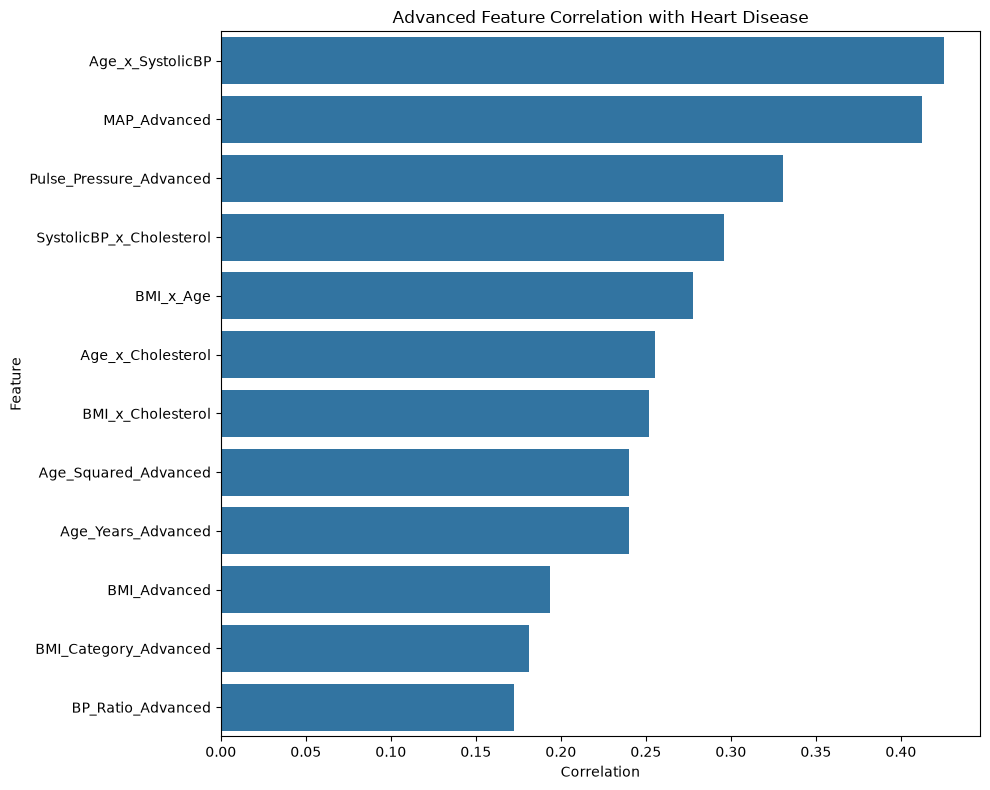

In [137]:
# ============================================================
# CELL 26 - CORRELATION VISUALIZATION
# ============================================================

plt.figure(figsize=(10, 8))

sns.barplot(
    x=advanced_correlations.values,
    y=advanced_correlations.index
)

plt.title(
    "Advanced Feature Correlation with Heart Disease"
)

plt.xlabel("Correlation")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [138]:
# ============================================================
# CELL 27 - FINAL DATASET SHAPE
# ============================================================

print("=" * 70)
print("FINAL DATASET SHAPE")
print("=" * 70)

print("Rows    :", df.shape[0])
print("Columns :", df.shape[1])

print("\nOriginal/Existing Features:")
print("Approximately 18 columns before advanced engineering.")

print("\nCurrent columns:")
for i, col in enumerate(df.columns, start=1):
    print(f"{i:2}. {col}")

FINAL DATASET SHAPE
Rows    : 68036
Columns : 24

Original/Existing Features:
Approximately 18 columns before advanced engineering.

Current columns:
 1. age
 2. gender
 3. height
 4. weight
 5. Systolic_BP
 6. Diastolic_BP
 7. cholesterol
 8. Glucose
 9. smoke
10. Alcohol
11. Physical_Activity
12. Heart_Disease
13. BMI
14. Pulse_Pressure
15. MAP
16. BMI_Category_Advanced
17. BP_Ratio_Advanced
18. Age_Years_Advanced
19. Age_Squared_Advanced
20. Age_x_SystolicBP
21. Age_x_Cholesterol
22. BMI_x_Cholesterol
23. SystolicBP_x_Cholesterol
24. BMI_x_Age


In [139]:
# ============================================================
# CELL 28 - FINAL DATA QUALITY CHECK
# ============================================================

print("=" * 70)
print("FINAL DATA QUALITY CHECK")
print("=" * 70)

print("Total rows    :", df.shape[0])
print("Total columns :", df.shape[1])

print("\nTotal missing values:",
      df.isnull().sum().sum())

print("Total duplicate rows:",
      df.duplicated().sum())

print("\nData types:")
display(df.dtypes.value_counts())

FINAL DATA QUALITY CHECK
Total rows    : 68036
Total columns : 24

Total missing values: 0
Total duplicate rows: 665

Data types:


float64    12
int64      12
Name: count, dtype: int64

In [140]:
# ============================================================
# CELL 29 - SAVE ADVANCED FEATURE DATASET
# ============================================================

output_folder = "../data/processed_data"

os.makedirs(
    output_folder,
    exist_ok=True
)

output_path = (
    output_folder +
    "/advanced_feature_engineered_dataset.csv"
)

df.to_csv(
    output_path,
    index=False
)

print("=" * 70)
print("DATASET SAVED SUCCESSFULLY")
print("=" * 70)

print("File:")
print(output_path)

print("\nRows    :", df.shape[0])
print("Columns :", df.shape[1])

DATASET SAVED SUCCESSFULLY
File:
../data/processed_data/advanced_feature_engineered_dataset.csv

Rows    : 68036
Columns : 24


In [141]:
# ============================================================
# CELL 30 - VERIFY SAVED DATASET
# ============================================================

if os.path.exists(output_path):

    file_size_mb = (
        os.path.getsize(output_path)
        / (1024 * 1024)
    )

    print("=" * 70)
    print("VERIFICATION SUCCESSFUL")
    print("=" * 70)

    print("File exists      : YES")
    print("File size        :", f"{file_size_mb:.2f} MB")
    print("Dataset rows     :", df.shape[0])
    print("Dataset columns  :", df.shape[1])

else:

    print("ERROR: File was not saved.")

VERIFICATION SUCCESSFUL
File exists      : YES
File size        : 8.90 MB
Dataset rows     : 68036
Dataset columns  : 24
